#**ZOMATO BANGALORE DATA ANALYSIS**:
**objective**:
To perform Exploratory Data Analysis (EDA) on the Zomato Bangalore dataset and generate
meaningful business insights using Python.


**IMPORTING NECESSARY PACKAGES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LOADING THE DATASET**

In [ ]:
df = pd.read_excel("/content/zomato_rest_data .xlsx")

#**Task 1: Data Understanding & Cleaning**
1. Dataset Exploration


In [ ]:
#DISPLAYING FIRST 5 ROWS
df.head()

,Unnamed: 0,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
#DISPLAYING SHAPE OF DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   51717 non-null  int64 
 1   url                          51717 non-null  object
 2   address                      51717 non-null  object
 3   name                         51717 non-null  object
 4   online_order                 51717 non-null  object
 5   book_table                   51717 non-null  object
 6   rate                         43942 non-null  object
 7   votes                        51717 non-null  int64 
 8   phone                        50509 non-null  object
 9   location                     51696 non-null  object
 10  rest_type                    51490 non-null  object
 11  dish_liked                   23639 non-null  object
 12  cuisines                     51672 non-null  object
 13  approx_cost(for two people)  51

In [ ]:
#LISTING COULUMNS
print(df.columns)

Index(['Unnamed: 0', 'url', 'address', 'name', 'online_order', 'book_table',
       'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked',
       'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


In [ ]:
#CHECKING DATATYPES
df.dtypes

,0
Unnamed: 0,int64
url,object
address,object
name,object
online_order,object
book_table,object
rate,object
votes,int64
phone,object
location,object


In [ ]:
#identifying missing values
missing_values = df.isnull().sum()
print(missing_values)

Unnamed: 0                         0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


#**Task 1: Data Understanding & Cleaning**
2. Data Cleaning


In [ ]:
#removing duplicate records
#1. PRINTING DUPLICATED RECORDS
duplicate_records = df.duplicated()
print(duplicate_records)
#2. remove duplicate records
df.drop_duplicates(inplace = True)


0        False
1        False
2        False
3        False
4        False
         ...  
51712    False
51713    False
51714    False
51715    False
51716    False
Length: 51717, dtype: bool


In [ ]:
# # Dropping columns tht r deemed insignificant to our analysis:
#1) phone number
#2) unnamed zero
#3) url
#4) we can remove location and keep listed in city
#5) we can remove restaurent type and keep listed in type
#6) reviews list
#7) address
#8) menu_item
df = df.drop(['phone','Unnamed: 0','url','address','phone','location','rest_type','menu_item','reviews_list'],axis = 1)


In [ ]:
df

,name,online_order,book_table,rate,votes,dish_liked,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,"Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Masala Dosa,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,NaN,Continental,"1,500",Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,NaN,0,NaN,Finger Food,600,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Finger Food,"2,000",Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500",Pubs and bars,Whitefield


In [ ]:
#Handling missing values in rate
#removing '/5'first
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.strip("/5")
df['rate'] = df['rate'].replace('NEW',0)
df['rate'] = df['rate'].replace('-',0)
df['rate'] = df['rate'].astype(float)
df['rate'] = df['rate'].fillna(df['rate'].mean())
df['rate'].unique()

array([4.1       , 3.8       , 3.7       , 3.6       , 4.6       ,
       4.        , 4.2       , 3.9       , 3.1       , 3.        ,
       3.2       , 3.3       , 2.8       , 4.4       , 4.3       ,
       0.        , 2.9       , 3.46840608, 2.6       , 3.4       ,
       2.        , 2.7       , 4.7       , 2.4       , 2.2       ,
       2.3       , 4.8       , 4.9       , 2.1       , 1.8       ])

In [ ]:
#handling missing values in avg_cost per 2
d = {'approx_cost(for two people)': 'avg_cost_for_two'}
df.rename(columns = d,inplace = True)
df['avg_cost_for_two'] = df['avg_cost_for_two'].astype(str)
df['avg_cost_for_two'] = df['avg_cost_for_two'].str.replace(',',"")
df['avg_cost_for_two'] = df['avg_cost_for_two'].astype(float)
df['avg_cost_for_two'] = df['avg_cost_for_two'].fillna(df['avg_cost_for_two'].mean())
df['avg_cost_for_two'].unique()


array([ 800.        ,  300.        ,  600.        ,  700.        ,
        550.        ,  500.        ,  450.        ,  650.        ,
        400.        ,  900.        ,  200.        ,  750.        ,
        150.        ,  850.        ,  100.        , 1200.        ,
        350.        ,  250.        ,  950.        , 1000.        ,
       1500.        , 1300.        ,  199.        ,   80.        ,
       1100.        ,  160.        , 1600.        ,  230.        ,
        130.        ,   50.        ,  190.        , 1700.        ,
        555.43156645, 1400.        ,  180.        , 1350.        ,
       2200.        , 2000.        , 1800.        , 1900.        ,
        330.        , 2500.        , 2100.        , 3000.        ,
       2800.        , 3400.        ,   40.        , 1250.        ,
       3500.        , 4000.        , 2400.        , 2600.        ,
        120.        , 1450.        ,  469.        ,   70.        ,
       3200.        ,   60.        ,  560.        ,  240.     

In [ ]:
#handling missing values in dish_liked column
df['dish_liked'].fillna(df['dish_liked'].mode()[0],inplace = True)
df['dish_liked'].unique()

/tmp/ipython-input-413/3402562540.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dish_liked'].fillna(df['dish_liked'].mode()[0],inplace = True)


array(['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup',
       'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani',
       'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza',
       ...,
       'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian',
       'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani',
       'Biryani, Andhra Meal'], dtype=object)

In [ ]:
#dealing with missing values in cuisine
df['cuisines'].fillna(df['cuisines'].mode()[0],inplace = True)
df['cuisines'].unique()

/tmp/ipython-input-413/2047347437.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cuisines'].fillna(df['cuisines'].mode()[0],inplace = True)


array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ...,
       'North Indian, Street Food, Biryani', 'Chinese, Mughlai',
       'North Indian, Chinese, Arabian, Momos'], dtype=object)

In [ ]:
#renaming columns
df.rename(columns = {'listed_in(type)':'type','listed_in(city)':'city'},inplace = True)

In [ ]:
#recalculating missing values
missing_values = df.isnull().sum()
print(missing_values)

name                0
online_order        0
book_table          0
rate                0
votes               0
dish_liked          0
cuisines            0
avg_cost_for_two    0
type                0
city                0
dtype: int64


#**Task 2: Univariate Analysis**:
Perform the following analysis with proper visualizations:
1) Top 5 locations with highest number of restaurants
2) Distribution of restaurant ratings
3) Percentage of restaurants offering online orders
4) Distribution of average cost for two

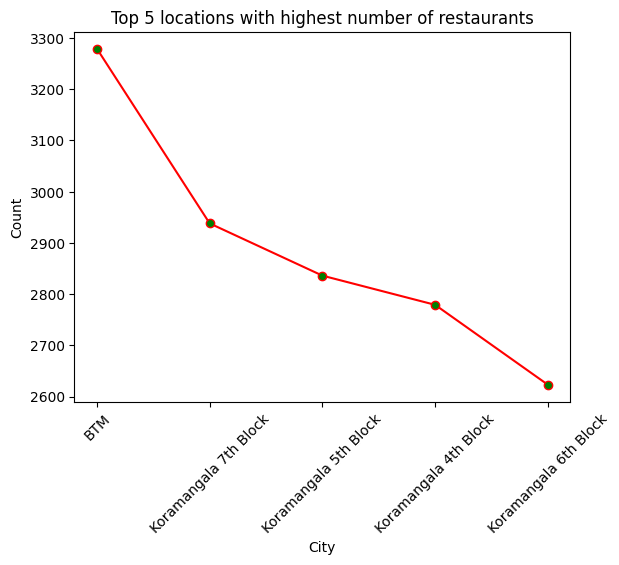

In [ ]:
#Top 5 locations with highest number of restaurants
top_5_locations = df['city'].value_counts().head(5)

plt.plot(top_5_locations.index,
         top_5_locations.values,
         color='red',
         linestyle='solid',
         marker='o',
         mfc='green',
         mec='red')

plt.xlabel("City")
plt.ylabel("Count")
plt.title("Top 5 locations with highest number of restaurants")
plt.xticks(rotation=45)
plt.show()


**BTM HAS THE HIGHEST NUMBER OF RESTAURENTS**

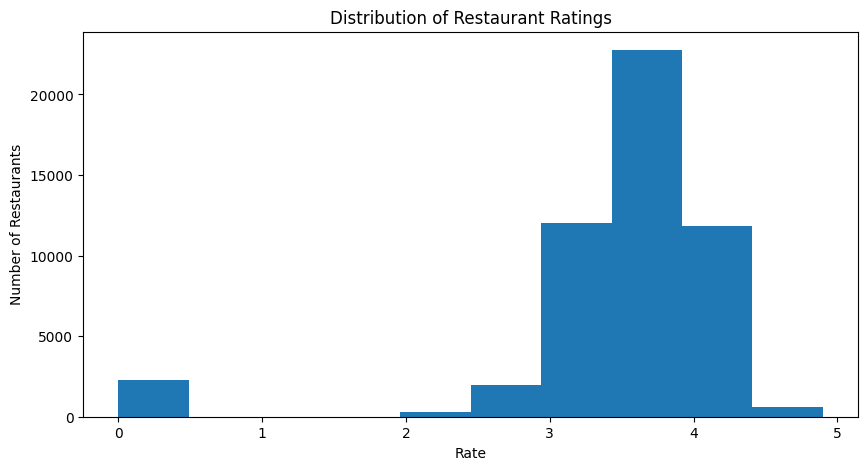

In [ ]:
#2.Distribution of restaurant ratings
plt.figure(figsize = (10,5))
plt.hist(df['rate'], bins=10)

plt.xlabel("Rate")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Ratings")

plt.show()




**many people had given 3-4 rating for over 20000 restaurents**

In [ ]:
#3. Percentage of restaurants offering online orders
df['online_order'].unique()
online_order_counts = df['online_order'].value_counts()
percentage = (online_order_counts / online_order_counts.sum()) * 100
print(percentage)

online_order
Yes    58.866524
No     41.133476
Name: count, dtype: float64


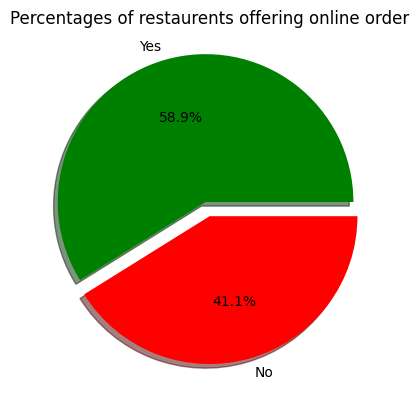

In [ ]:
#graphical representation
plt.pie(percentage,labels = percentage.index, autopct='%1.1f%%',colors = ['green','red'],shadow = True,explode=(0.1,0))
plt.title("Percentages of restaurents offering online order")
plt.show()

**MAJORITY OF THE RESTAURENTS OFFER ONLINE ORDER SYSTEM**

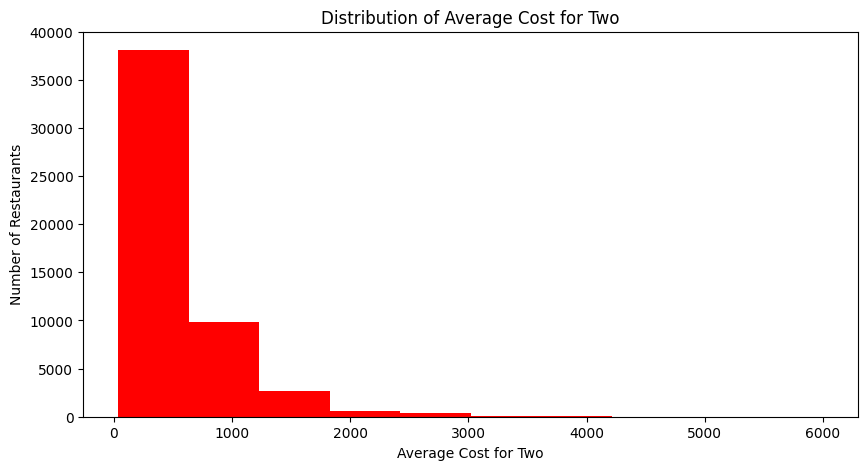

In [ ]:
# 4. Distribution of average cost for two
plt.figure(figsize = (10,5))
plt.hist(df['avg_cost_for_two'],bins=10,color = 'red')
plt.xlabel("Average Cost for Two")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Average Cost for Two")
plt.show()

**AVERAGE COST FOR 2 FOR MOST RESTAURENTS IS BETWEEN 0 AND 1000**

#**Task 3: Bivariate Analysis**:
Analyze the relationship between:
1) Rating vs Cost
2) Rating vs Online Order
3) Votes vs Rating
4) Use appropriate plots (scatter plot, box plot, bar chart, etc.)


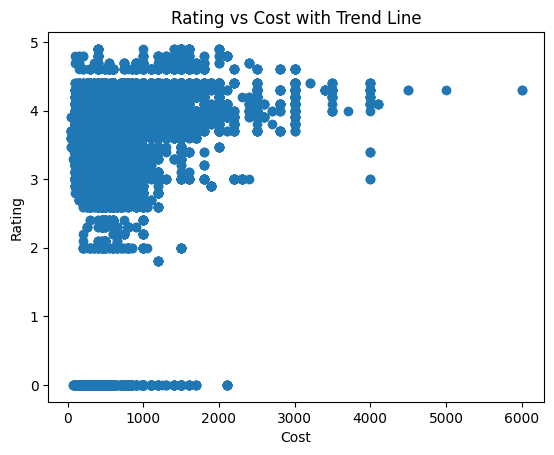

In [ ]:
#1. RATING VS COST
x = df['avg_cost_for_two']
y = df['rate']

plt.scatter(x, y)
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.title("Rating vs Cost with Trend Line")

plt.show()


**While higher-cost restaurants tend to have slightly better ratings, there is significant variation among lower-cost restaurants. This suggests that price alone is not a strong predictor of customer satisfaction.**

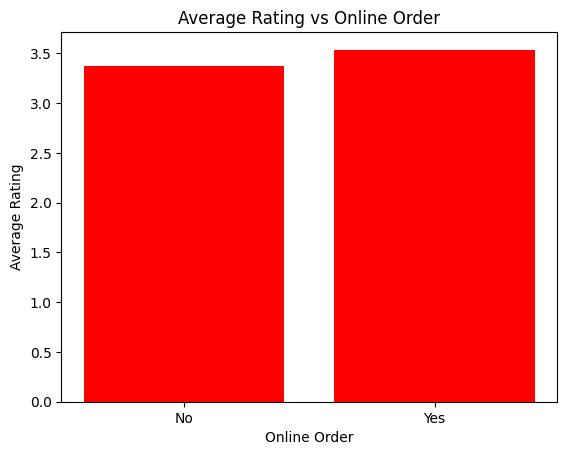

In [ ]:
#2. Rating vs Online Order - customers r liking if u provide or not provide online order
#average rating based on online order
online_order_rating = df.groupby('online_order')['rate'].mean()
#graphical representation
plt.bar(online_order_rating.index, online_order_rating.values,color = 'red')
plt.xlabel("Online Order")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Online Order")

plt.show()


**PEOPLE ARE LIKING THE RESTAURENT WITH OR WITHOUT ONLINE ORDER**

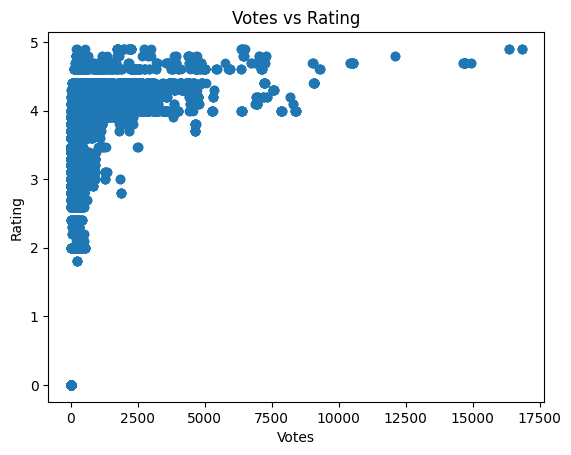

In [ ]:
#3. Votes vs Rating
plt.scatter(df['votes'], df['rate'])

plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")

plt.show()


**Restaurants with higher votes tend to have consistently higher ratings, indicating that popular restaurants generally maintain good customer satisfaction. However, restaurants with fewer votes show greater variability in ratings.**

#**Task 4: Business Insights & Recommendations**:
Based on your analysis, answer the following:
1) Does higher cost lead to higher ratings?

2) Does offering online order impact ratings?
3) Which location appears highly competitive?
4) Where would you recommend opening a new restaurant?

#**ANSWERS**:
1) yes , higher cost leads to higher ratings
2) CUSTOMERS are liking restaurents with or without online orders equally
3) BTM appers to be highly competitive area
4) in areas with less restaurents , we can open new restaurents

In [ ]:
#save cleaned data
df.to_csv("cleaned data.csv")